In [2]:
"""
Map Detection Training Notebook

This notebook trains a YOLOv8 model to detect map games in images.
The pipeline includes dataset preparation, train/val splitting, model training,
validation, and model export.

Author: NCSU - Fall 2025 Board Game Project
"""

# ============================================================================
# IMPORTS
# ============================================================================

import os
import shutil
import random
from pathlib import Path
from ultralytics import YOLO  # YOLOv8 implementation
import yaml  # For creating configuration files
import torch  # PyTorch deep learning framework
from torch.serialization import add_safe_globals
from ultralytics.nn.tasks import DetectionModel

In [3]:
# ============================================================================
# STEP 1: SETUP DATASET PATHS
# ============================================================================

# Define base directory containing the dataset
base_dir = Path("/mnt/e/NCSU/Fall_2025/Board Game/map_detection/map_dataset")

# Paths to augmented images and labels (created by data_augmentation.py)
images_dir = base_dir / "images"
labels_dir = base_dir / "labels"

# Output directory structure for YOLO training
output_dir = base_dir / "yolo_dataset"
train_images = output_dir / "train/images"
train_labels = output_dir / "train/labels"
val_images   = output_dir / "val/images"
val_labels   = output_dir / "val/labels"

# Create output directories (uncomment to run)
# This will create the train/val directory structure
for d in [train_images, train_labels, val_images, val_labels]:
    d.mkdir(parents=True, exist_ok=True)

In [ ]:
# ============================================================================
# STEP 2: TRAIN/VALIDATION SPLIT
# ============================================================================

# Collect all image files from augmented dataset
all_images = list(images_dir.glob("*.jpg")) + list(images_dir.glob("*.png"))

# Set random seed for reproducible splits
random.seed(42)
random.shuffle(all_images)

# Split dataset: 80% training, 20% validation
split_idx = int(0.8 * len(all_images))
train_files = all_images[:split_idx]
val_files   = all_images[split_idx:]

# Function to copy image and label files to train/val directories
def copy_files(file_list, dest_img_dir, dest_lbl_dir):
    """Copy images and their corresponding label files to destination"""
    for img_path in file_list:
        # Find corresponding label file
        lbl_path = labels_dir / (img_path.stem + ".txt")
        if lbl_path.exists():
            # Copy both image and label
            shutil.copy(img_path, dest_img_dir / img_path.name)
            shutil.copy(lbl_path, dest_lbl_dir / lbl_path.name)

# Copy files to their respective directories (uncomment to run)
copy_files(train_files, train_images, train_labels)
copy_files(val_files, val_images, val_labels)

print(f"Copied {len(train_files)} train and {len(val_files)} val images.")

Copied 304 train and 77 val images.


In [4]:
# ============================================================================
# STEP 3: CREATE YOLO CONFIGURATION FILE (data.yaml)
# ============================================================================

# YOLO requires a data.yaml file that specifies:
# - Paths to training and validation datasets
# - Number of classes (nc)
# - Class names

data_yaml = {
    "train": str(train_images.parent.resolve()),  # Path to train directory
    "val": str(val_images.parent.resolve()),      # Path to val directory
    "nc": 1,                                      # Number of classes (1 = map)
    "names": ["map"]                            # Class name(s)
}

# Write configuration to data.yaml file (uncomment to run)
with open(output_dir / "data.yaml", "w") as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

print(f"data.yaml created at {output_dir / 'data.yaml'}")

data.yaml created at /mnt/e/NCSU/Fall_2025/Board Game/map_detection/map_dataset/yolo_dataset/data.yaml


In [5]:
# ============================================================================
# STEP 4: CHECK FOR GPU AVAILABILITY
# ============================================================================

# Check if CUDA-compatible GPU is available
# Training on GPU is significantly faster than CPU
if torch.cuda.is_available():
    device = 0  # Use first GPU
    print(f"✅ Using GPU: {torch.cuda.get_device_name(0)}")
else:
    device = "cpu"  # Fall back to CPU
    print("⚠️ CUDA not available, falling back to CPU")
    print("Note: Training on CPU will be much slower. Consider using Google Colab with GPU.")

✅ Using GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [6]:
# ============================================================================
# STEP 5: TRAIN YOLO MODEL
# ============================================================================

# Load pre-trained YOLOv8 nano model
# yolov8n.pt is the smallest/fastest model
# For better accuracy, try: yolov8s.pt, yolov8m.pt, or yolov8l.pt
model = YOLO("yolov8n.pt")

# Train the model with specified parameters
results = model.train(
    data=str(output_dir / "data.yaml"),  # Path to data configuration file
    epochs=20,                           # Number of training epochs (increase for better results)
    imgsz=640,                          # Input image size (smaller = faster, larger = better accuracy)
    batch=4,                            # Batch size (reduce if out of memory)
    device=device,                       # Device: "cpu" or 0 for GPU
    workers=0,                          # Number of data loader workers (0 = disable multiprocessing)
    cache=True,                         # Cache images in RAM for faster training
    patience=5,                         # Early stopping: stop if no improvement for 5 epochs
    name="map-detector",              # Name for this training run
    exist_ok=True,                      # Allow overwriting existing run
    verbose=True                        # Print training progress
)

# Training outputs:
# - Model checkpoints saved to: runs/detect/map-detector/weights/
# - Training logs and visualizations in: runs/detect/map-detector/
# - Best model: best.pt, Last model: last.pt

New https://pypi.org/project/ultralytics/8.4.31 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.209 🚀 Python-3.10.18 torch-2.8.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/mnt/e/NCSU/Fall_2025/Board Game/map_detection/map_dataset/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, m

In [7]:
# ============================================================================
# STEP 6: VALIDATE MODEL PERFORMANCE
# ============================================================================

# Run validation on the validation set
# This calculates metrics like precision, recall, mAP (mean Average Precision)
metrics = model.val()

# Print validation metrics
print("\n=== Validation Metrics ===")
print(metrics)
print("\nKey metrics to check:")
print("- mAP50: Mean Average Precision at IoU threshold 0.5")
print("- mAP50-95: Mean Average Precision averaged over IoU 0.5-0.95")
print("- Precision: Accuracy of positive predictions")
print("- Recall: Fraction of actual maps detected")

Ultralytics 8.3.209 🚀 Python-3.10.18 torch-2.8.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)


Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 2.8±0.1 ms, read: 110.1±7.4 MB/s, size: 2431.3 KB)
val: Scanning /mnt/e/NCSU/Fall_2025/Board Game/map_detection/map_dataset/yolo_dataset/val/labels.cache... 77 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 77/77 93.3Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 0.9it/s 5.9s0.6ss
                   all         77         77      0.999          1      0.995      0.989
Speed: 4.0ms preprocess, 8.0ms inference, 0.0ms loss, 3.1ms postprocess per image
Results saved to /mnt/e/NCSU/Fall_2025/Board Game/map_detection/runs/detect/val2

=== Validation Metrics ===
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x74e718259660>
curves: ['Precision-Reca

In [8]:
# ============================================================================
# STEP 7: TEST INFERENCE ON SAMPLE IMAGE
# ============================================================================

# Run inference on a random validation image to test the model
test_img = random.choice(val_files)
pred = model(str(test_img), save=True)

print(f"Inference saved for {test_img.name}")
print(f"Results saved to: runs/detect/predict/")
print("\nTo view the result, check the generated image with bounding boxes.")


image 1/1 /mnt/e/NCSU/Fall_2025/Board Game/map_detection/map_dataset/images/400b82b0-10-22-25-C-task-action-2040-1.jpg: 640x384 1 map, 63.5ms
Speed: 12.9ms preprocess, 63.5ms inference, 6.8ms postprocess per image at shape (1, 3, 640, 384)
Results saved to /mnt/e/NCSU/Fall_2025/Board Game/map_detection/runs/detect/predict2
Inference saved for 400b82b0-10-22-25-C-task-action-2040-1.jpg
Results saved to: runs/detect/predict/

To view the result, check the generated image with bounding boxes.


In [9]:
# ============================================================================
# STEP 8: SAVE TRAINED MODEL
# ============================================================================

# Create directory for saving models
model_save_dir = Path("saved_models")
model_save_dir.mkdir(exist_ok=True)

# Copy the best weights from training to saved_models directory
# The best.pt file contains the model weights from the epoch with best validation performance
model_path = model_save_dir / "map_detector_v1.pt"
shutil.copy("runs/detect/map-detector/weights/best.pt", model_path)
print(f"✅ Model saved to {model_path}")

# ============================================================================
# LOADING AND USING THE SAVED MODEL
# ============================================================================

print(val_files)
# Load the saved model for inference
loaded_model = YOLO(model_path)

def detect_map(image_path):
    """
    Detect maps in an image using the trained model.
    
    Args:
        image_path (str): Path to the image file
        
    Returns:
        Detection results containing bounding boxes, confidence scores, etc.
    """
    results = loaded_model(image_path)
    return results[0]  # Return first (and only) detection result

# # Test the loaded model on a validation image
test_img = random.choice(val_files)
result = detect_map(str(test_img))
print(f"\n=== Detection Test ===")
print(f"Test image: {test_img.name}")
print(f"Detected {len(result.boxes)} maps in test image")

# Access detection details
if len(result.boxes) > 0:
    for i, box in enumerate(result.boxes):
        print(f"\nMap {i+1}:")
        print(f"  - Confidence: {box.conf[0]:.3f}")
        print(f"  - Bounding box: {box.xyxy[0].tolist()}")  # [x1, y1, x2, y2]

✅ Model saved to saved_models/map_detector_v1.pt
[PosixPath('/mnt/e/NCSU/Fall_2025/Board Game/map_detection/map_dataset/images/3b5ff05f-10-22-25-C-task-envr-2050-3.jpg'), PosixPath('/mnt/e/NCSU/Fall_2025/Board Game/map_detection/map_dataset/images/16838d4d-10-31-25-A-task-action-2040-1_after.jpg'), PosixPath('/mnt/e/NCSU/Fall_2025/Board Game/map_detection/map_dataset/images/58a63fb1-10-23-25-B-setup-2030-2.jpg'), PosixPath('/mnt/e/NCSU/Fall_2025/Board Game/map_detection/map_dataset/images/48d60c23-11-03-25-A-task-env-2040-2_after.jpg'), PosixPath('/mnt/e/NCSU/Fall_2025/Board Game/map_detection/map_dataset/images/7a0edcc4-10-23-25-E-task-env-2030-1_after.jpg'), PosixPath('/mnt/e/NCSU/Fall_2025/Board Game/map_detection/map_dataset/images/82b0b1d6-10-31-25-C-task-action-2040-1_after.jpg'), PosixPath('/mnt/e/NCSU/Fall_2025/Board Game/map_detection/map_dataset/images/383109de-10-22-25-E-task-action-2040-2.jpg'), PosixPath('/mnt/e/NCSU/Fall_2025/Board Game/map_detection/map_dataset/images/7d

In [10]:
# ============================================================================ 
# STEP 9: FIND IMAGES WITH INACCURATE MAP DETECTION
# ============================================================================ 

from pathlib import Path
import numpy as np

def compute_iou(boxA, boxB):
    # boxA and boxB: [x1, y1, x2, y2]
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])
    interArea = max(0, xB - xA) * max(0, yB - yA)
    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    iou = interArea / float(boxAArea + boxBArea - interArea + 1e-6)
    return iou

def parse_yolo_label(label_path, img_w, img_h):
    # YOLO format: class x_center y_center width height (all normalized)
    with open(label_path, 'r') as f:
        line = f.readline().strip()
        if not line:
            return None
        parts = line.split()
        if len(parts) < 5:
            return None
        _, x, y, w, h = map(float, parts)
        x1 = (x - w/2) * img_w
        y1 = (y - h/2) * img_h
        x2 = (x + w/2) * img_w
        y2 = (y + h/2) * img_h
        return [x1, y1, x2, y2]

from PIL import Image

bad_images = []
iou_threshold = 0.5  # Set your threshold for "accurate" detection

for img_path in val_files:
    label_path = labels_dir / (img_path.stem + ".txt")
    if not label_path.exists():
        continue
    img = Image.open(img_path)
    img_w, img_h = img.size
    gt_box = parse_yolo_label(label_path, img_w, img_h)
    if gt_box is None:
        continue
    result = detect_map(str(img_path))
    pred_boxes = [box.xyxy[0].cpu().numpy() for box in result.boxes]
    if not pred_boxes:
        bad_images.append(str(img_path))
        continue
    # Compute IoU for each predicted box with ground truth, take max
    ious = [compute_iou(gt_box, pred_box) for pred_box in pred_boxes]
    max_iou = max(ious) if ious else 0
    if max_iou < iou_threshold:
        bad_images.append(str(img_path))

print(f"Images with inaccurate map detection (IoU < {iou_threshold}):")
for bad_img in bad_images:
    print(bad_img)

image 1/1 /mnt/e/NCSU/Fall_2025/Board Game/map_detection/map_dataset/images/3b5ff05f-10-22-25-C-task-envr-2050-3.jpg: 640x384 1 map, 52.8ms
Speed: 2.2ms preprocess, 52.8ms inference, 2.6ms postprocess per image at shape (1, 3, 640, 384)

image 1/1 /mnt/e/NCSU/Fall_2025/Board Game/map_detection/map_dataset/images/16838d4d-10-31-25-A-task-action-2040-1_after.jpg: 384x640 1 map, 11.1ms
Speed: 2.3ms preprocess, 11.1ms inference, 2.6ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /mnt/e/NCSU/Fall_2025/Board Game/map_detection/map_dataset/images/58a63fb1-10-23-25-B-setup-2030-2.jpg: 384x640 1 map, 8.6ms
Speed: 2.1ms preprocess, 8.6ms inference, 2.4ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /mnt/e/NCSU/Fall_2025/Board Game/map_detection/map_dataset/images/48d60c23-11-03-25-A-task-env-2040-2_after.jpg: 384x640 1 map, 8.7ms
Speed: 2.0ms preprocess, 8.7ms inference, 2.8ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /mnt/e/NCSU/Fall_2025/Board Game/


image 1/1 /mnt/e/NCSU/Fall_2025/Board Game/map_detection/map_dataset/images/ce9cead7-Grad-2040.jpg: 640x480 1 map, 95.0ms
Speed: 7.1ms preprocess, 95.0ms inference, 7.0ms postprocess per image at shape (1, 3, 640, 480)


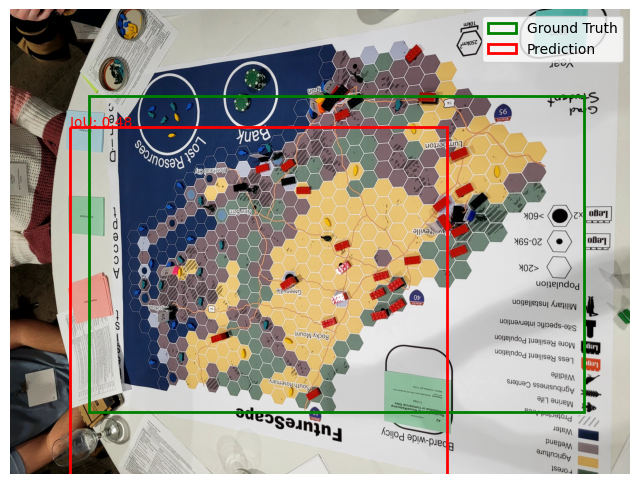


image 1/1 /mnt/e/NCSU/Fall_2025/Board Game/map_detection/map_dataset/images/dece8c13-10-31-25-A-task-env-2040-1_after.jpg: 384x640 1 map, 38.4ms
Speed: 3.9ms preprocess, 38.4ms inference, 6.6ms postprocess per image at shape (1, 3, 384, 640)


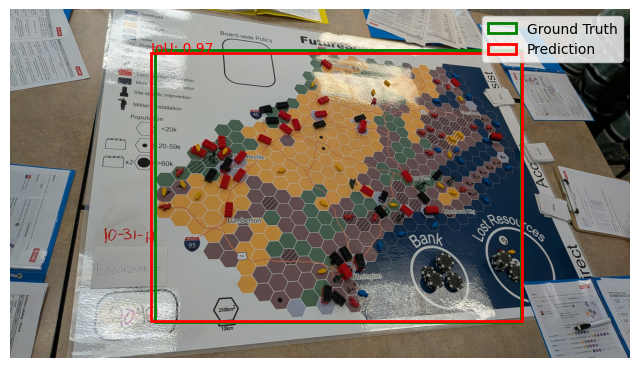

In [13]:
# ============================================================================ 
# STEP 10: VISUALIZE PREDICTED VS GROUND TRUTH BOXES
# ============================================================================ 

import matplotlib.pyplot as plt
import matplotlib.patches as patches

def show_image_with_boxes(img_path, gt_box, pred_boxes, iou_list=None):
    img = Image.open(img_path)
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    ax.imshow(img)
    # Draw ground truth box (green)
    if gt_box is not None:
        rect = patches.Rectangle((gt_box[0], gt_box[1]), gt_box[2]-gt_box[0], gt_box[3]-gt_box[1],
                                 linewidth=2, edgecolor='g', facecolor='none', label='Ground Truth')
        ax.add_patch(rect)
    # Draw predicted boxes (red)
    for i, pred_box in enumerate(pred_boxes):
        rect = patches.Rectangle((pred_box[0], pred_box[1]), pred_box[2]-pred_box[0], pred_box[3]-pred_box[1],
                                 linewidth=2, edgecolor='r', facecolor='none', label='Prediction' if i==0 else None)
        ax.add_patch(rect)
        if iou_list is not None:
            ax.text(pred_box[0], pred_box[1]-10, f'IoU: {iou_list[i]:.2f}', color='red', fontsize=10)
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys())
    plt.axis('off')
    plt.show()

# Example: Visualize a bad image (first in the list)
if bad_images:
    img_path = bad_images[-1]
    label_path = labels_dir / (Path(img_path).stem + ".txt")
    img = Image.open(img_path)
    img_w, img_h = img.size
    gt_box = parse_yolo_label(label_path, img_w, img_h)
    result = detect_map(str(img_path))
    pred_boxes = [box.xyxy[0].cpu().numpy() for box in result.boxes]
    ious = [compute_iou(gt_box, pred_box) for pred_box in pred_boxes] if gt_box is not None and pred_boxes else None
    show_image_with_boxes(img_path, gt_box, pred_boxes, ious)

# To visualize a good image, pick one not in bad_images
good_images = [str(p) for p in val_files if str(p) not in bad_images]
if good_images:
    img_path = good_images[-1]
    label_path = labels_dir / (Path(img_path).stem + ".txt")
    img = Image.open(img_path)
    img_w, img_h = img.size
    gt_box = parse_yolo_label(label_path, img_w, img_h)
    result = detect_map(str(img_path))
    pred_boxes = [box.xyxy[0].cpu().numpy() for box in result.boxes]
    ious = [compute_iou(gt_box, pred_box) for pred_box in pred_boxes] if gt_box is not None and pred_boxes else None
    show_image_with_boxes(img_path, gt_box, pred_boxes, ious)